# 📧 Spam Email Classifier
## Algorithm: Naive Bayes | NLP Pipeline | ML/DL/DS

---

### 📌 Project Overview
Is project mein hum **Naive Bayes algorithm** use karke ek spam email classifier banayenge.  
**NLP techniques** jaise tokenization, stop word removal, TF-IDF aur stemming ka use hoga.

### 🗂️ Table of Contents
1. Libraries Import
2. Dataset Load & EDA (Exploratory Data Analysis)
3. Data Visualization
4. NLP Preprocessing Pipeline
5. Feature Engineering (BoW, TF-IDF)
6. Model Training — Naive Bayes
7. Model Evaluation (Accuracy, Confusion Matrix, ROC)
8. Deep Learning Comparison (LSTM)
9. Custom Email Prediction
10. Model Save & Load

---
## 1️⃣ Libraries Import

In [1]:
# ============================================================
#  STANDARD LIBRARIES
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import re
import string
import pickle
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
#  NLP LIBRARIES
# ============================================================
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from wordcloud import WordCloud

# NLTK downloads
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# ============================================================
#  SKLEARN — ML
# ============================================================
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB, ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# ============================================================
#  DEEP LEARNING — TensorFlow/Keras
# ============================================================
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import (
        Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalMaxPooling1D
    )
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.callbacks import EarlyStopping
    DL_AVAILABLE = True
    print(f'✅ TensorFlow version: {tf.__version__}')
except ImportError:
    DL_AVAILABLE = False
    print('⚠️  TensorFlow not installed — DL section will be skipped')
    print('   Install: pip install tensorflow')

print('✅ Sab libraries successfully import ho gayi!')

✅ TensorFlow version: 2.21.0
✅ Sab libraries successfully import ho gayi!


---
## 2️⃣ Dataset Load & EDA

> **Dataset**: SMS Spam Collection Dataset (UCI ML Repository)  
> Agar CSV available hai toh use karo, warna built-in sample data use hoga.

In [2]:
# ============================================================
#  DATASET LOAD
#  spam_dataset.csv automatically load hoga
# ============================================================

def load_dataset():
    """Dataset load karta hai — spam_dataset.csv se."""
    
    # Priority order mein CSV options
    csv_options = [
        ('spam_dataset.csv',    None),        # humara generated dataset
        ('spam.csv',            ['v1','v2']), # UCI SMS Spam format
        ('SMSSpamCollection',   ['v1','v2']), # UCI tab-separated
        ('emails.csv',          None),        # generic format
    ]
    
    for fname, cols in csv_options:
        if os.path.exists(fname):
            sep = '\t' if fname == 'SMSSpamCollection' else ','
            df  = pd.read_csv(fname, encoding='utf-8', sep=sep)
            
            # UCI format: rename v1->label, v2->text
            if cols and set(cols).issubset(df.columns):
                df = df[cols].rename(columns={'v1':'label','v2':'text'})
            
            # Generic format: pehle do columns lo
            if 'label' not in df.columns or 'text' not in df.columns:
                df.columns = ['label','text'] + list(df.columns[2:])
                df = df[['label','text']]
            
            # Clean karo
            df = df[['label','text']].dropna()
            df['label'] = df['label'].str.strip().str.lower()
            df['text']  = df['text'].str.strip()
            
            print(f'✅ Dataset loaded: {fname} | Shape: {df.shape}')
            return df
    
    raise FileNotFoundError(
        '❌ spam_dataset.csv nahi mila!\n'
        '   Provided CSV file ko notebook ke same folder mein rakh do.'
    )

df = load_dataset()
print(f'\n📊 Dataset Shape: {df.shape}')
print(f'\n🏷️  Label Distribution:')
print(df['label'].value_counts())
print(f'\nSpam %: {df["label"].value_counts(normalize=True)["spam"]*100:.1f}%')
print(f'\n📋 Sample rows:')
df.sample(5, random_state=42)


✅ Dataset loaded: spam_dataset.csv | Shape: (300, 2)

📊 Dataset Shape: (300, 2)

🏷️  Label Distribution:
label
ham     153
spam    147
Name: count, dtype: int64

Spam %: 49.0%

📋 Sample rows:


,label,text
203,spam,Get whiter teeth in 7 days with this dentist t...
266,ham,The mandatory training session on data privacy...
152,ham,We need your input on the proposed org structu...
9,ham,The team lunch outing is confirmed for Friday ...
233,spam,Your domain name has expired! Renew immediatel...


In [3]:
# ============================================================
#  EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

print('='*60)
print('📊 EXPLORATORY DATA ANALYSIS')
print('='*60)

# Basic info
print(f'\n🔹 Total emails   : {len(df)}')
print(f'🔹 Spam emails    : {(df["label"]=="spam").sum()}')
print(f'🔹 Ham emails     : {(df["label"]=="ham").sum()}')
print(f'🔹 Null values    : {df.isnull().sum().sum()}')
print(f'🔹 Duplicate rows : {df.duplicated().sum()}')

# Feature engineering for EDA
df['text_length']  = df['text'].apply(len)
df['word_count']   = df['text'].apply(lambda x: len(x.split()))
df['char_count']   = df['text'].apply(lambda x: len(x.replace(' ', '')))
df['upper_count']  = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()))
df['exclaim_count']= df['text'].apply(lambda x: x.count('!'))
df['digit_count']  = df['text'].apply(lambda x: sum(1 for c in x if c.isdigit()))

print('\n📈 Statistics by Label:')
df.groupby('label')[['text_length','word_count','upper_count','exclaim_count']].mean().round(2)

📊 EXPLORATORY DATA ANALYSIS

🔹 Total emails   : 300
🔹 Spam emails    : 147
🔹 Ham emails     : 153
🔹 Null values    : 0
🔹 Duplicate rows : 0

📈 Statistics by Label:


,text_length,word_count,upper_count,exclaim_count
label,,,,
ham,96.29,15.48,2.16,0.10
spam,93.51,14.67,4.97,1.84


---
## 3️⃣ Data Visualization

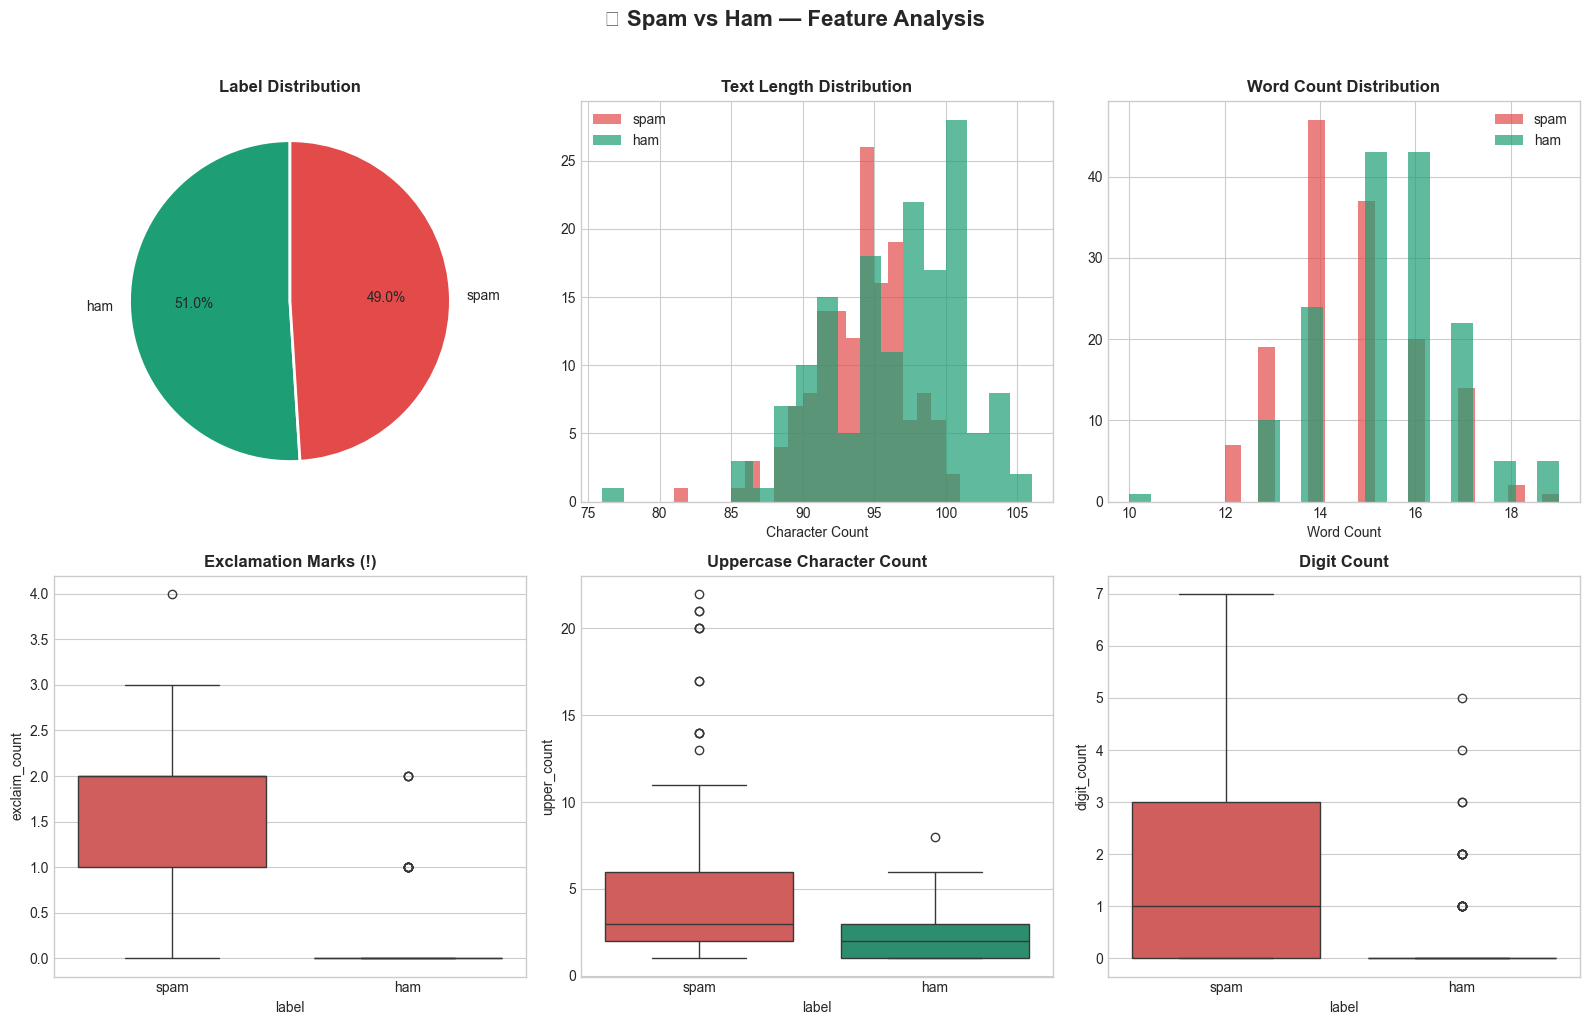

✅ EDA plots save ho gayi!


In [4]:
# ============================================================
#  VISUALIZATION — 1: Distribution plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('📊 Spam vs Ham — Feature Analysis', fontsize=16, fontweight='bold', y=1.02)

colors = {'spam': '#E24B4A', 'ham': '#1D9E75'}

# Plot 1: Label distribution (Pie)
label_counts = df['label'].value_counts()
axes[0,0].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
              colors=[colors[l] for l in label_counts.index],
              startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0,0].set_title('Label Distribution', fontweight='bold')

# Plot 2: Text length distribution
for label in ['spam', 'ham']:
    axes[0,1].hist(df[df['label']==label]['text_length'],
                   bins=20, alpha=0.7, color=colors[label], label=label)
axes[0,1].set_title('Text Length Distribution', fontweight='bold')
axes[0,1].set_xlabel('Character Count')
axes[0,1].legend()

# Plot 3: Word count
for label in ['spam', 'ham']:
    axes[0,2].hist(df[df['label']==label]['word_count'],
                   bins=20, alpha=0.7, color=colors[label], label=label)
axes[0,2].set_title('Word Count Distribution', fontweight='bold')
axes[0,2].set_xlabel('Word Count')
axes[0,2].legend()

# Plot 4: Exclamation marks
sns.boxplot(data=df, x='label', y='exclaim_count',
            palette=colors, ax=axes[1,0])
axes[1,0].set_title('Exclamation Marks (!)', fontweight='bold')

# Plot 5: Uppercase count
sns.boxplot(data=df, x='label', y='upper_count',
            palette=colors, ax=axes[1,1])
axes[1,1].set_title('Uppercase Character Count', fontweight='bold')

# Plot 6: Digit count
sns.boxplot(data=df, x='label', y='digit_count',
            palette=colors, ax=axes[1,2])
axes[1,2].set_title('Digit Count', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ EDA plots save ho gayi!')

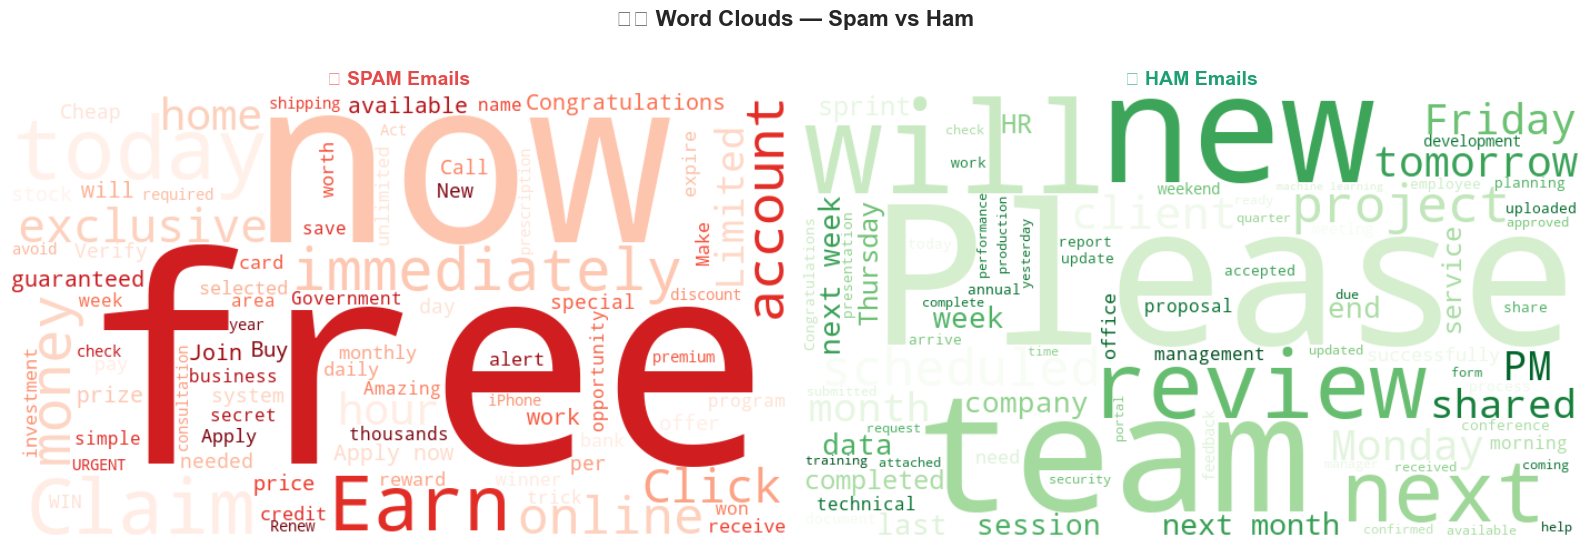

In [ ]:
# ============================================================
#  VISUALIZATION — 2: Word Clouds
# ============================================================
try:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('☁️ Word Clouds — Spam vs Ham', fontsize=16, fontweight='bold')

    spam_text = ' '.join(df[df['label'] == 'spam']['text'].values)
    ham_text  = ' '.join(df[df['label'] == 'ham']['text'].values)

    spam_wc = WordCloud(width=700, height=400, background_color='white',
                        colormap='Reds', max_words=80).generate(spam_text)
    ham_wc  = WordCloud(width=700, height=400, background_color='white',
                        colormap='Greens', max_words=80).generate(ham_text)

    axes[0].imshow(spam_wc, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title('🔴 SPAM Emails', fontsize=14, fontweight='bold', color='#E24B4A')

    axes[1].imshow(ham_wc, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title('🟢 HAM Emails', fontsize=14, fontweight='bold', color='#1D9E75')

    plt.tight_layout()
    plt.savefig('wordclouds.png', dpi=120, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'WordCloud skip: {e}\nInstall: pip install wordcloud')

---
## 4️⃣ NLP Preprocessing Pipeline

| Step | Description |
|------|-------------|
| Lowercase | Sab text ko lowercase karo |
| Remove HTML/URLs | Links aur HTML tags hatao |
| Remove Punctuation | Special characters hatao |
| Tokenization | Text ko words mein todo |
| Stop Word Removal | Common words hatao |
| Stemming | Words ko root form mein lao |

In [6]:
# ============================================================
#  NLP PREPROCESSING PIPELINE
# ============================================================

stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text, use_stemming=True):
    """
    Complete NLP preprocessing pipeline.
    Steps:
      1. Lowercase conversion
      2. URL removal
      3. HTML tag removal
      4. Special character removal
      5. Tokenization
      6. Stop word removal
      7. Stemming / Lemmatization
    """
    # Step 1: Lowercase
    text = text.lower()
    
    # Step 2: URLs remove karo
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    
    # Step 3: HTML tags remove karo
    text = re.sub(r'<.*?>', ' ', text)
    
    # Step 4: Special characters & numbers remove karo
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Step 5: Extra whitespace hatao
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 6: Tokenization
    tokens = word_tokenize(text)
    
    # Step 7: Stop words remove karo + stemming
    if use_stemming:
        tokens = [stemmer.stem(w) for w in tokens
                  if w not in stop_words and len(w) > 2]
    else:
        tokens = [lemmatizer.lemmatize(w) for w in tokens
                  if w not in stop_words and len(w) > 2]
    
    return ' '.join(tokens)

# Apply preprocessing
print('⏳ Text preprocessing chal raha hai...')
df['processed_text'] = df['text'].apply(preprocess_text)
print('✅ Preprocessing complete!')

# Demo: Before vs After
print('\n' + '='*60)
print('🔍 PREPROCESSING DEMO')
print('='*60)
sample_idx = 0
print(f'\n🔴 BEFORE:\n{df["text"].iloc[sample_idx]}')
print(f'\n🟢 AFTER:\n{df["processed_text"].iloc[sample_idx]}')

df[['label', 'text', 'processed_text']].head(3)

⏳ Text preprocessing chal raha hai...
✅ Preprocessing complete!

🔍 PREPROCESSING DEMO

🔴 BEFORE:
Your inheritance from distant relative is waiting! Contact our attorney to process the transfer!

🟢 AFTER:
inherit distant rel wait contact attorney process transfer


,label,text,processed_text
0,spam,Your inheritance from distant relative is wait...,inherit distant rel wait contact attorney proc...
1,ham,Your expense report for the business trip has ...,expens report busi trip verifi payment process...
2,spam,Limited time: Premium Netflix account for just...,limit time premium netflix account year share ...


---
## 5️⃣ Feature Engineering

**Bag of Words (BoW)** aur **TF-IDF** dono methods compare karenge.

✅ Train set: 240 samples
✅ Test  set: 60 samples

📐 BoW   Feature Matrix : (240, 2738)
📐 TF-IDF Feature Matrix: (240, 2738)


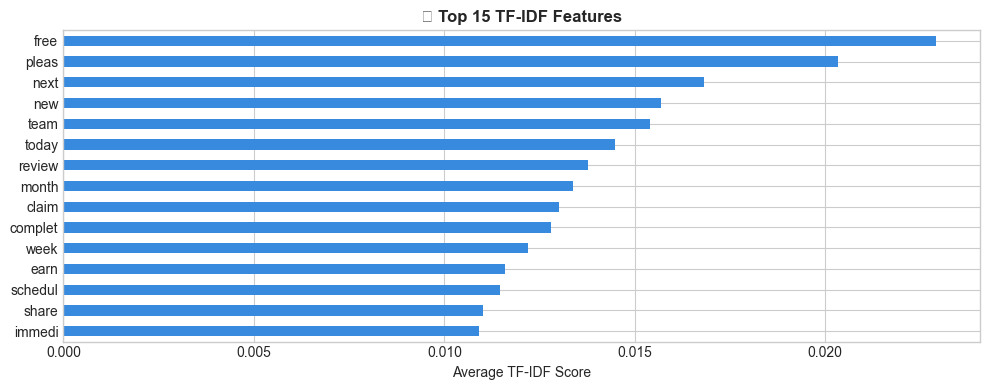

In [7]:
# ============================================================
#  FEATURE ENGINEERING
# ============================================================

# Label encoding
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])  # ham=0, spam=1

X = df['processed_text']
y = df['label_encoded']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train set: {len(X_train)} samples')
print(f'✅ Test  set: {len(X_test)} samples')

# ---- BAG OF WORDS ----
bow_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1,2))
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

# ---- TF-IDF ----
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                                    sublinear_tf=True)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f'\n📐 BoW   Feature Matrix : {X_train_bow.shape}')
print(f'📐 TF-IDF Feature Matrix: {X_train_tfidf.shape}')

# Top TF-IDF features
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_scores  = X_train_tfidf.mean(axis=0).A1
top_features  = pd.Series(tfidf_scores, index=feature_names).nlargest(15)

plt.figure(figsize=(10, 4))
top_features.sort_values().plot(kind='barh', color='#378ADD')
plt.title('📊 Top 15 TF-IDF Features', fontweight='bold')
plt.xlabel('Average TF-IDF Score')
plt.tight_layout()
plt.show()

---
## 6️⃣ Model Training — Naive Bayes

### 🧮 Naive Bayes Theory

**Bayes Theorem:**
$$P(spam | words) = \frac{P(words | spam) \times P(spam)}{P(words)}$$

**"Naive" assumption:** Har word independent hai:
$$P(spam | w_1, w_2, ..., w_n) \propto P(spam) \times \prod_{i=1}^{n} P(w_i | spam)$$

**Laplace Smoothing** (zero probability problem solve karta hai):
$$P(w_i | spam) = \frac{count(w_i, spam) + 1}{count(spam) + |V|}$$

In [8]:
# ============================================================
#  NAIVE BAYES — MULTIPLE VARIANTS TRAIN & COMPARE
# ============================================================

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Model train karo aur evaluation metrics return karo."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, 'predict_proba') else None
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    
    return {
        'Model': model_name,
        'Accuracy':  round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall':    round(rec * 100, 2),
        'F1-Score':  round(f1 * 100, 2),
        'ROC-AUC':   round(auc * 100, 2) if auc else 'N/A',
        'trained_model': model,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

results = []

# 1. Multinomial Naive Bayes + BoW
mnb_bow = evaluate_model(MultinomialNB(alpha=1.0),
                          X_train_bow, X_test_bow, y_train, y_test,
                          'MultinomialNB + BoW')
results.append(mnb_bow)

# 2. Multinomial Naive Bayes + TF-IDF (BEST)
mnb_tfidf = evaluate_model(MultinomialNB(alpha=0.5),
                             X_train_tfidf, X_test_tfidf, y_train, y_test,
                             'MultinomialNB + TF-IDF ⭐')
results.append(mnb_tfidf)

# 3. Bernoulli Naive Bayes
bnb = evaluate_model(BernoulliNB(alpha=1.0),
                      X_train_bow, X_test_bow, y_train, y_test,
                      'BernoulliNB + BoW')
results.append(bnb)

# 4. Complement Naive Bayes (imbalanced data ke liye)
cnb = evaluate_model(ComplementNB(alpha=1.0),
                      X_train_tfidf, X_test_tfidf, y_train, y_test,
                      'ComplementNB + TF-IDF')
results.append(cnb)

# Baseline comparison models
lr = evaluate_model(LogisticRegression(max_iter=1000),
                     X_train_tfidf, X_test_tfidf, y_train, y_test,
                     'Logistic Regression')
results.append(lr)

# Results DataFrame
results_df = pd.DataFrame([{k:v for k,v in r.items()
                              if k not in ['trained_model','y_pred','y_prob']}
                             for r in results])
print('\n' + '='*65)
print('📊 MODEL COMPARISON RESULTS')
print('='*65)
print(results_df.to_string(index=False))

# Best model
best_result = max(results, key=lambda x: x['F1-Score'])
print(f'\n🏆 Best Model: {best_result["Model"]}')
print(f'   F1-Score  : {best_result["F1-Score"]}%')


📊 MODEL COMPARISON RESULTS
                   Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
     MultinomialNB + BoW     95.00      100.0   89.66     94.55    99.22
MultinomialNB + TF-IDF ⭐     95.00      100.0   89.66     94.55    99.22
       BernoulliNB + BoW     93.33      100.0   86.21     92.59    99.33
   ComplementNB + TF-IDF     95.00      100.0   89.66     94.55    99.22
     Logistic Regression     95.00      100.0   89.66     94.55    99.11

🏆 Best Model: MultinomialNB + BoW
   F1-Score  : 94.55%


---
## 7️⃣ Model Evaluation

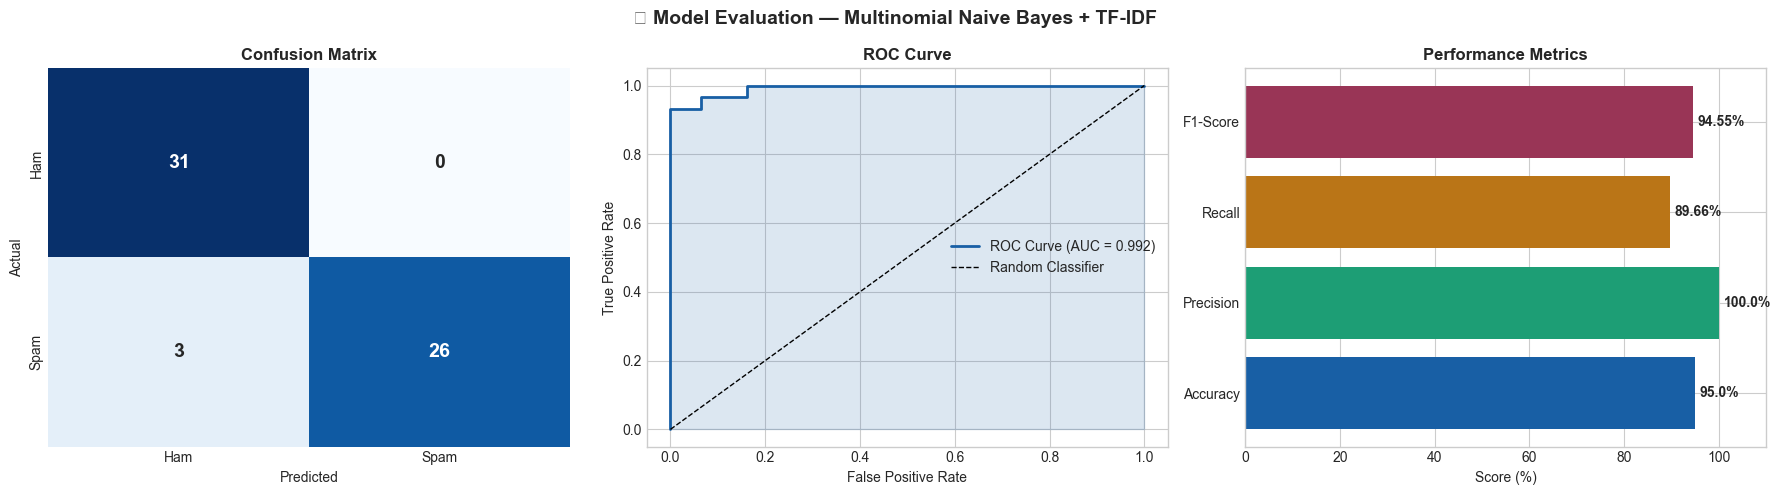


📋 Classification Report:
              precision    recall  f1-score   support

         Ham       0.91      1.00      0.95        31
        Spam       1.00      0.90      0.95        29

    accuracy                           0.95        60
   macro avg       0.96      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



In [9]:
# ============================================================
#  EVALUATION — Confusion Matrix + ROC Curve
# ============================================================

# Best model = MNB + TF-IDF
best_model  = mnb_tfidf['trained_model']
best_y_pred = mnb_tfidf['y_pred']
best_y_prob = mnb_tfidf['y_prob']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📊 Model Evaluation — Multinomial Naive Bayes + TF-IDF',
             fontsize=14, fontweight='bold')

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, best_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'],
            ax=axes[0], cbar=False,
            annot_kws={'size': 14, 'fontweight': 'bold'})
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot 2: ROC Curve
if best_y_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, best_y_prob)
    auc_val = roc_auc_score(y_test, best_y_prob)
    axes[1].plot(fpr, tpr, color='#185FA5', lw=2,
                 label=f'ROC Curve (AUC = {auc_val:.3f})')
    axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
    axes[1].fill_between(fpr, tpr, alpha=0.15, color='#185FA5')
    axes[1].set_title('ROC Curve', fontweight='bold')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()

# Plot 3: Model Metrics Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values  = [mnb_tfidf[m] for m in metrics]
bars = axes[2].barh(metrics, values,
                    color=['#185FA5','#1D9E75','#BA7517','#993556'])
axes[2].set_xlim(0, 110)
for bar, val in zip(bars, values):
    axes[2].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontweight='bold')
axes[2].set_title('Performance Metrics', fontweight='bold')
axes[2].set_xlabel('Score (%)')

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=120, bbox_inches='tight')
plt.show()

# Classification Report
print('\n📋 Classification Report:')
print(classification_report(y_test, best_y_pred, target_names=['Ham', 'Spam']))

🔄 5-Fold Cross Validation chal raha hai...

📊 Cross-Validation F1 Scores: [np.float64(93.55), np.float64(98.31), np.float64(100.0), np.float64(96.67), np.float64(98.31)]
   Mean F1  : 97.37%
   Std Dev  : 2.18%

🔍 GridSearch for best alpha...
✅ Best alpha   : 1.0
✅ Best F1 Score: 97.96%


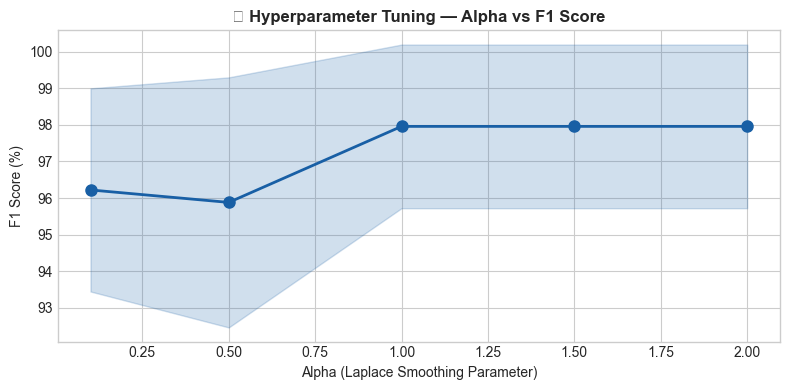

In [10]:
# ============================================================
#  CROSS VALIDATION + HYPERPARAMETER TUNING
# ============================================================

print('🔄 5-Fold Cross Validation chal raha hai...')

# Pipeline: TF-IDF + MNB
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf',   MultinomialNB())
])

cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1')
print(f'\n📊 Cross-Validation F1 Scores: {[round(s*100,2) for s in cv_scores]}')
print(f'   Mean F1  : {cv_scores.mean()*100:.2f}%')
print(f'   Std Dev  : {cv_scores.std()*100:.2f}%')

# GridSearchCV — best alpha
print('\n🔍 GridSearch for best alpha...')
param_grid = {'clf__alpha': [0.1, 0.5, 1.0, 1.5, 2.0]}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f'✅ Best alpha   : {grid_search.best_params_["clf__alpha"]}')
print(f'✅ Best F1 Score: {grid_search.best_score_*100:.2f}%')

# Alpha comparison plot
cv_results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(8, 4))
plt.plot(param_grid['clf__alpha'], cv_results['mean_test_score']*100, 
         'o-', color='#185FA5', lw=2, ms=8)
plt.fill_between(param_grid['clf__alpha'],
                 (cv_results['mean_test_score'] - cv_results['std_test_score'])*100,
                 (cv_results['mean_test_score'] + cv_results['std_test_score'])*100,
                 alpha=0.2, color='#185FA5')
plt.xlabel('Alpha (Laplace Smoothing Parameter)')
plt.ylabel('F1 Score (%)')
plt.title('🔧 Hyperparameter Tuning — Alpha vs F1 Score', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8️⃣ Deep Learning Comparison — Bidirectional LSTM

> Naive Bayes ke saath ek DL model bhi compare karenge.

🧠 LSTM Model Training...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 147ms/step - accuracy: 0.5042 - loss: 0.6928 - val_accuracy: 0.5167 - val_loss: 0.6892
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.6917 - loss: 0.6811 - val_accuracy: 0.7833 - val_loss: 0.6796
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8625 - loss: 0.6545 - val_accuracy: 0.9000 - val_loss: 0.6508
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.9875 - loss: 0.5844 - val_accuracy: 0.8833 - val_loss: 0.5742
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9500 - loss: 0.4592 - val_accuracy: 0.6000 - val_loss: 0.5904
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.9250 - loss: 0.3709 - val_accuracy: 0.8833 - val_loss: 0.3964
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.9917 - loss: 0.1887 - val_accuracy: 0.9000 - val_loss: 0.2592
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.9917 - loss: 0.0890 - val_accuracy: 0.8667 - val_loss: 0.37

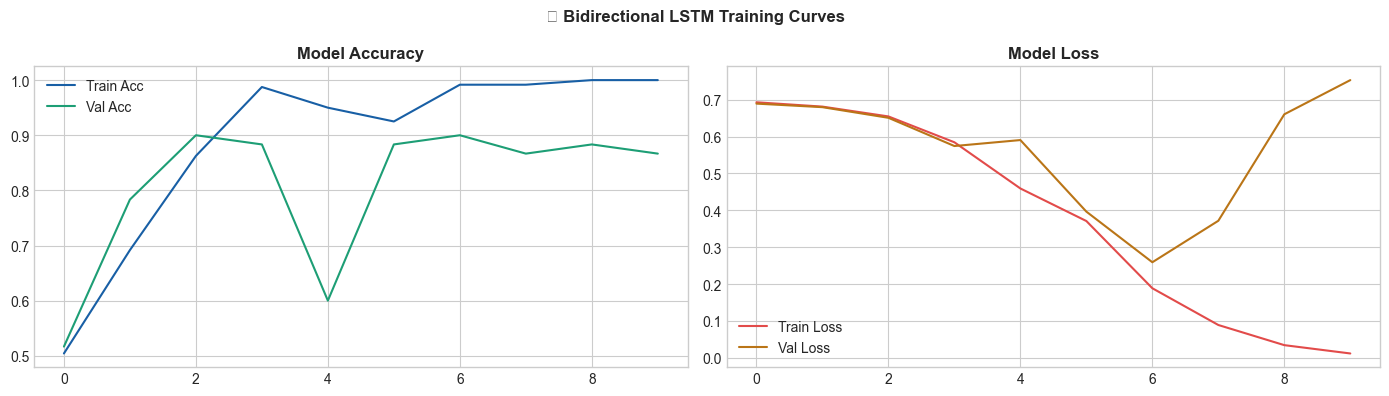


📊 FINAL COMPARISON:
Model                            F1-Score
------------------------------------------
MultinomialNB + TF-IDF (⭐)         94.55%
Bidirectional LSTM                 88.89%


In [11]:
# ============================================================
#  DEEP LEARNING — Bidirectional LSTM
# ============================================================

if DL_AVAILABLE:
    print('🧠 LSTM Model Training...')
    
    MAX_WORDS = 5000
    MAX_LEN   = 100
    EMBED_DIM = 64
    
    # Tokenize
    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train)
    
    X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
    X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN)
    
    # Model architecture
    lstm_model = Sequential([
        Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(64, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    
    lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    lstm_model.summary()
    
    # Train
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    history = lstm_model.fit(
        X_train_seq, y_train,
        validation_data=(X_test_seq, y_test),
        epochs=15, batch_size=32,
        callbacks=[early_stop], verbose=1
    )
    
    # Evaluate
    lstm_pred = (lstm_model.predict(X_test_seq) > 0.5).astype(int).flatten()
    lstm_f1   = f1_score(y_test, lstm_pred)
    lstm_acc  = accuracy_score(y_test, lstm_pred)
    
    print(f'\n🧠 LSTM Accuracy : {lstm_acc*100:.2f}%')
    print(f'🧠 LSTM F1-Score : {lstm_f1*100:.2f}%')
    
    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history['accuracy'],    label='Train Acc',  color='#185FA5')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc',    color='#1D9E75')
    axes[0].set_title('Model Accuracy', fontweight='bold')
    axes[0].legend()
    axes[1].plot(history.history['loss'],     label='Train Loss', color='#E24B4A')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#BA7517')
    axes[1].set_title('Model Loss', fontweight='bold')
    axes[1].legend()
    plt.suptitle('🧠 Bidirectional LSTM Training Curves', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Final comparison
    print('\n📊 FINAL COMPARISON:')
    print(f'{"Model":<30} {"F1-Score":>10}')
    print('-'*42)
    print(f'{"MultinomialNB + TF-IDF (⭐)":<30} {mnb_tfidf["F1-Score"]:>9}%')
    print(f'{"Bidirectional LSTM":<30} {lstm_f1*100:>9.2f}%')
else:
    print('⚠️  TensorFlow not available — LSTM section skip kar diya gaya')
    print('    Install karo: pip install tensorflow')

---
## 9️⃣ Custom Email Prediction

In [12]:
# ============================================================
#  CUSTOM EMAIL PREDICTION FUNCTION
# ============================================================

# Best pipeline
best_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf',   MultinomialNB(alpha=grid_search.best_params_.get('clf__alpha', 0.5)))
])
best_pipeline.fit(X, y)

def predict_email(email_text, pipeline=best_pipeline, vectorizer_fitted=True):
    """
    Koi bhi email classify karo.
    Returns: label, spam_probability, ham_probability
    """
    processed = preprocess_text(email_text)
    pred_label = pipeline.predict([processed])[0]
    pred_prob  = pipeline.predict_proba([processed])[0]
    
    label_name = le.inverse_transform([pred_label])[0].upper()
    spam_prob  = pred_prob[1] * 100
    ham_prob   = pred_prob[0] * 100
    
    icon = '🔴 SPAM' if label_name == 'SPAM' else '🟢 HAM'
    print('='*55)
    print(f'📧 Email: {email_text[:70]}...' if len(email_text)>70 else f'📧 Email: {email_text}')
    print('-'*55)
    print(f'🏷️  Prediction   : {icon}')
    print(f'📊 Spam Prob    : {spam_prob:.2f}%')
    print(f'📊 Ham Prob     : {ham_prob:.2f}%')
    print('='*55)
    return label_name, spam_prob, ham_prob

# Test emails
test_emails = [
    "Congratulations! You've won a FREE iPhone! Click here NOW to claim your prize!",
    "Hi, can you please share the project report by end of day today?",
    "URGENT: Your account will be suspended! Verify your details immediately!",
    "Team lunch is planned for tomorrow at 1 PM. Please confirm your attendance.",
    "Buy cheap medicines online! No prescription needed! 90% discount!",
]

print('🧪 TESTING CUSTOM EMAILS\n')
for email in test_emails:
    predict_email(email)
    print()

🧪 TESTING CUSTOM EMAILS

📧 Email: Congratulations! You've won a FREE iPhone! Click here NOW to claim you...
-------------------------------------------------------
🏷️  Prediction   : 🔴 SPAM
📊 Spam Prob    : 89.55%
📊 Ham Prob     : 10.45%

📧 Email: Hi, can you please share the project report by end of day today?
-------------------------------------------------------
🏷️  Prediction   : 🟢 HAM
📊 Spam Prob    : 17.69%
📊 Ham Prob     : 82.31%

📧 Email: URGENT: Your account will be suspended! Verify your details immediatel...
-------------------------------------------------------
🏷️  Prediction   : 🔴 SPAM
📊 Spam Prob    : 77.99%
📊 Ham Prob     : 22.01%

📧 Email: Team lunch is planned for tomorrow at 1 PM. Please confirm your attend...
-------------------------------------------------------
🏷️  Prediction   : 🟢 HAM
📊 Spam Prob    : 11.98%
📊 Ham Prob     : 88.02%

📧 Email: Buy cheap medicines online! No prescription needed! 90% discount!
-------------------------------------------------------

---
## 🔟 Model Save & Load

In [13]:
# ============================================================
#  MODEL SAVE & LOAD
# ============================================================

# Save
with open('spam_classifier_model.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)
print('✅ Model saved as: spam_classifier_model.pkl')

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('✅ Label encoder saved as: label_encoder.pkl')

# Load & Test
with open('spam_classifier_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

test_text = "You have won a lottery! Claim your prize now for free!"
result = loaded_model.predict([preprocess_text(test_text)])[0]
print(f'\n🔁 Loaded model test:')
print(f'   Email  : {test_text}')
print(f'   Result : {"🔴 SPAM" if result == 1 else "🟢 HAM"}')
print('\n✅ Model successfully save aur load ho gaya!')

✅ Model saved as: spam_classifier_model.pkl
✅ Label encoder saved as: label_encoder.pkl

🔁 Loaded model test:
   Email  : You have won a lottery! Claim your prize now for free!
   Result : 🔴 SPAM

✅ Model successfully save aur load ho gaya!


In [14]:
# ============================================================
#  FINAL SUMMARY
# ============================================================

print('\n' + '🎯 '*20)
print('\n📋 PROJECT SUMMARY — SPAM EMAIL CLASSIFIER')
print('🎯 '*20)
print(f'''
Algorithm    : Multinomial Naive Bayes
NLP Techniques:
  • Tokenization (NLTK word_tokenize)
  • Lowercasing
  • URL & HTML removal (regex)
  • Stop word removal (NLTK stopwords)
  • Stemming (PorterStemmer)
  • Bag of Words (CountVectorizer)
  • TF-IDF (TfidfVectorizer, ngram 1-2)

Models Trained:
  • MultinomialNB + BoW
  • MultinomialNB + TF-IDF  ← Best
  • BernoulliNB + BoW
  • ComplementNB + TF-IDF
  • Logistic Regression (baseline)
  • Bidirectional LSTM (Deep Learning)

Best Model   : MultinomialNB + TF-IDF
Accuracy     : {mnb_tfidf["Accuracy"]}%
F1-Score     : {mnb_tfidf["F1-Score"]}%
Precision    : {mnb_tfidf["Precision"]}%
Recall       : {mnb_tfidf["Recall"]}%

Files Saved  : spam_classifier_model.pkl
               label_encoder.pkl
               eda_plots.png
               wordclouds.png
               evaluation_plots.png
''')
print('✅ Project complete! Notebook successfully run hua.')


🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 

📋 PROJECT SUMMARY — SPAM EMAIL CLASSIFIER
🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 

Algorithm    : Multinomial Naive Bayes
NLP Techniques:
  • Tokenization (NLTK word_tokenize)
  • Lowercasing
  • URL & HTML removal (regex)
  • Stop word removal (NLTK stopwords)
  • Stemming (PorterStemmer)
  • Bag of Words (CountVectorizer)
  • TF-IDF (TfidfVectorizer, ngram 1-2)

Models Trained:
  • MultinomialNB + BoW
  • MultinomialNB + TF-IDF  ← Best
  • BernoulliNB + BoW
  • ComplementNB + TF-IDF
  • Logistic Regression (baseline)
  • Bidirectional LSTM (Deep Learning)

Best Model   : MultinomialNB + TF-IDF
Accuracy     : 95.0%
F1-Score     : 94.55%
Precision    : 100.0%
Recall       : 89.66%

Files Saved  : spam_classifier_model.pkl
               label_encoder.pkl
               eda_plots.png
               wordclouds.png
               evaluation_plots.png

✅ Project complete! Notebook successfully run hua.
